# Checkpoint 4 — Probabilidade e Distribuição Normal aplicadas à Inteligência Artificial

**Statistical Computing with R & Python** — Prof. Me. Eng. Rodolfo Magliari de Paiva
2º Semestre, Tecnólogo em Inteligência Artificial, FIAP

**Integrantes**
- Giovanni Henrique Pereira Hessel (RM 570574)
- Suellen Pereira da Silva (RM 573862)
- Arthur Zeferino (RM 570858)
- Israel Carneiro de Toledo (RM 573854)

**Aplicação (Logística):** prever o atraso de entregas de uma transportadora urbana que promete entregar em até 60 minutos (SLA). Todos os dados são simulados por números pseudoaleatórios com semente fixa, portanto o resultado é sempre o mesmo.

Como rodar no Colab: menu **Ambiente de execução → Executar tudo** (ou Ctrl+F9). Todas as bibliotecas usadas já vêm instaladas no Colab.

## 0. Bibliotecas e configurações

Rode esta célula primeiro.

In [1]:
"""
====================================================================
 CHECKPOINT 4 - Statistical Computing with R & Python
 2o Semestre - Tecnologo em Inteligencia Artificial - FIAP
 Professor: Me. Eng. Rodolfo Magliari de Paiva

 TEMAS: 1) Probabilidade e a Inteligencia Artificial
        2) Distribuicao Normal e a Inteligencia Artificial

 APLICACAO (area de LOGISTICA): previsao de atraso em entregas
 de uma transportadora urbana. Todos os dados sao SIMULADOS
 (gerados por numeros pseudoaleatorios com semente fixa), portanto
 o experimento e 100% reproduzivel e nao usa dados reais.

 INTEGRANTES:
   Giovanni Henrique Pereira Hessel  - RM 570574
   Suellen Pereira da Silva          - RM 573862
   Arthur Zeferino                   - RM 570858
   Israel Carneiro de Toledo         - RM 573854

 Execucao:  python codigo_cp4.py
 Depende de: numpy, pandas, matplotlib, scipy
====================================================================
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# --------------------------------------------------------------
# CONFIGURACOES GERAIS
# --------------------------------------------------------------
SEMENTE = 42                 # semente do gerador pseudoaleatorio
N_ENTREGAS = 1000            # tamanho da base simulada
SLA_MINUTOS = 60             # prazo prometido ao cliente (minutos)
PASTA_GRAFICOS = "graficos"   # no Colab os graficos aparecem na tela e ficam salvos nesta pasta

COR_A = "#065A82"   # azul profundo - classe "no prazo"
COR_B = "#D1495B"   # coral - classe "atraso"
COR_C = "#1C7293"   # teal  - destaques

os.makedirs(PASTA_GRAFICOS, exist_ok=True)
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})


def titulo(texto):
    """Imprime um cabecalho de secao padronizado no terminal."""
    print("\n" + "=" * 68)
    print(f" {texto}")
    print("=" * 68)


# ==============================================================
# 1) NUMEROS PSEUDOALEATORIOS E GERACAO DA BASE SIMULADA

## 1. Gerando a base com números pseudoaleatórios

O computador não sorteia de verdade: ele parte de uma semente e devolve valores que parecem sorteados. Com a semente fixa em 42, o resultado é sempre o mesmo, então qualquer pessoa consegue repetir e conferir as contas.

In [2]:
# ==============================================================
# O computador nao produz numeros verdadeiramente aleatorios: ele usa
# um algoritmo deterministico (gerador pseudoaleatorio) que, a partir
# de uma semente (seed), gera uma sequencia que se comporta como
# aleatoria. Fixar a semente garante reprodutibilidade cientifica.
def gerar_base(n=N_ENTREGAS, semente=SEMENTE):
    rng = np.random.default_rng(semente)

    # Distancia da entrega (km) ~ Normal(12; 4), truncada em 1 km
    distancia = np.clip(rng.normal(12, 4, n), 1, None)

    # Chuva no momento da entrega ~ Bernoulli(p = 0,30)
    chuva = rng.binomial(1, 0.30, n)

    # Horario de pico ~ Bernoulli(p = 0,40)
    pico = rng.binomial(1, 0.40, n)

    # Tempo de entrega (min) = tempo base + efeitos + ruido normal
    #   6 min fixos de coleta + 3 min por km + 12 min se chove
    #   + 9 min se horario de pico + erro ~ Normal(0; 7)
    tempo = (6 + 3.0 * distancia + 12 * chuva + 9 * pico
             + rng.normal(0, 7, n))
    tempo = np.clip(tempo, 5, None)

    df = pd.DataFrame({
        "distancia_km": np.round(distancia, 2),
        "chuva": chuva,
        "horario_pico": pico,
        "tempo_min": np.round(tempo, 1),
    })
    # Variavel-alvo: 1 = entrega atrasada (estourou o SLA)
    df["atraso"] = (df["tempo_min"] > SLA_MINUTOS).astype(int)
    return df


# ==============================================================
# 2) PROBABILIDADE APLICADA

## 2. Probabilidade: simples, condicional e Teorema de Bayes

Aqui calculamos a chance de atraso no geral e em cada cenário (com chuva, no horário de pico, nos dois ao mesmo tempo), além de aplicar o Teorema de Bayes e conferir o resultado na própria base.

In [3]:
# ==============================================================
# Conceitos usados:
#   P(A)         = casos favoraveis / casos possiveis  (freq. relativa)
#   P(A|B)       = P(A e B) / P(B)                     (condicional)
#   Bayes:  P(B|A) = P(A|B) * P(B) / P(A)
def analise_probabilidade(df):
    titulo("2. PROBABILIDADE - QUANTIFICANDO O RISCO DE ATRASO")

    n = len(df)
    p_atraso = df["atraso"].mean()
    p_chuva = df["chuva"].mean()
    p_pico = df["horario_pico"].mean()

    print(f"Entregas simuladas          : {n}")
    print(f"P(atraso)                   : {p_atraso:.3f}")
    print(f"P(chuva)                    : {p_chuva:.3f}")
    print(f"P(horario de pico)          : {p_pico:.3f}")

    # Probabilidades condicionais
    p_atraso_chuva = df.loc[df["chuva"] == 1, "atraso"].mean()
    p_atraso_sem_chuva = df.loc[df["chuva"] == 0, "atraso"].mean()
    p_atraso_pico = df.loc[df["horario_pico"] == 1, "atraso"].mean()
    p_atraso_chuva_pico = df.loc[(df["chuva"] == 1) &
                                 (df["horario_pico"] == 1), "atraso"].mean()

    print("\n--- Probabilidades condicionais ---")
    print(f"P(atraso | chuva)           : {p_atraso_chuva:.3f}")
    print(f"P(atraso | sem chuva)       : {p_atraso_sem_chuva:.3f}")
    print(f"P(atraso | pico)            : {p_atraso_pico:.3f}")
    print(f"P(atraso | chuva e pico)    : {p_atraso_chuva_pico:.3f}")
    print(f"Risco relativo (chuva)      : {p_atraso_chuva / p_atraso_sem_chuva:.2f}x")

    # Teorema de Bayes: dado que a entrega atrasou, qual a chance de ter chovido?
    p_chuva_dado_atraso = (p_atraso_chuva * p_chuva) / p_atraso
    print("\n--- Teorema de Bayes ---")
    print("P(chuva|atraso) = P(atraso|chuva) * P(chuva) / P(atraso)")
    print(f"                = {p_atraso_chuva:.3f} * {p_chuva:.3f} / {p_atraso:.3f}"
          f" = {p_chuva_dado_atraso:.3f}")
    print(f"Verificacao empirica        : {df.loc[df['atraso'] == 1, 'chuva'].mean():.3f}")

    # Tabela de contingencia (probabilidades conjuntas)
    print("\n--- Tabela de contingencia (probabilidades conjuntas) ---")
    print(pd.crosstab(df["chuva"], df["atraso"], normalize="all")
          .rename(index={0: "sem chuva", 1: "com chuva"},
                  columns={0: "no prazo", 1: "atraso"}).round(3))

    # Grafico: risco de atraso por cenario
    cenarios = ["Sem chuva\nsem pico", "So pico", "So chuva", "Chuva\n+ pico"]
    valores = [
        df.loc[(df["chuva"] == 0) & (df["horario_pico"] == 0), "atraso"].mean(),
        df.loc[(df["chuva"] == 0) & (df["horario_pico"] == 1), "atraso"].mean(),
        df.loc[(df["chuva"] == 1) & (df["horario_pico"] == 0), "atraso"].mean(),
        p_atraso_chuva_pico,
    ]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    barras = ax.bar(cenarios, valores, color=[COR_A, COR_A, COR_B, COR_B], width=0.6)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.0%}",
                ha="center", fontweight="bold")
    ax.axhline(p_atraso, ls="--", color="gray")
    ax.text(-0.42, p_atraso + 0.03, f"media geral {p_atraso:.0%}", ha="left",
            color="gray", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("P(atraso)")
    ax.set_title("Probabilidade condicional de atraso por cenario operacional")
    fig.tight_layout()
    fig.savefig(os.path.join(PASTA_GRAFICOS, "g1_probabilidade_condicional.png"))
    plt.show()

    return {"p_atraso": p_atraso, "p_atraso_chuva": p_atraso_chuva,
            "p_atraso_sem_chuva": p_atraso_sem_chuva,
            "p_chuva_dado_atraso": p_chuva_dado_atraso}


# ==============================================================
# 3) DISTRIBUICAO NORMAL

## 3. Distribuição Normal

Ajustamos a curva Normal ao tempo de entrega, aplicamos o teste de Shapiro-Wilk, conferimos a regra 68-95-99,7 e calculamos a chance de estourar o prazo de 60 minutos usando o escore z. O último gráfico mostra o Teorema Central do Limite.

In [4]:
# ==============================================================
# f(x) = 1 / (sigma * raiz(2*pi)) * e^(-((x - mu)^2) / (2*sigma^2))
# z = (x - mu) / sigma
def analise_normal(df):
    titulo("3. DISTRIBUICAO NORMAL - MODELANDO O TEMPO DE ENTREGA")

    x = df["tempo_min"]
    mu, sigma = x.mean(), x.std(ddof=1)
    print(f"Media (mu)                  : {mu:.2f} min")
    print(f"Desvio-padrao (sigma)       : {sigma:.2f} min")
    print(f"Mediana                     : {x.median():.2f} min")
    print(f"Assimetria                  : {stats.skew(x):.3f} (0 = simetrica)")
    print(f"Curtose                     : {stats.kurtosis(x):.3f} (0 = normal)")

    # Teste de normalidade de Shapiro-Wilk (H0: os dados sao normais)
    stat_sw, p_sw = stats.shapiro(x.sample(500, random_state=SEMENTE))
    print(f"\nShapiro-Wilk: W = {stat_sw:.4f} | p-valor = {p_sw:.4f}")
    print("Conclusao   :", "nao rejeitamos H0 -> compativel com a Normal"
          if p_sw > 0.05 else "rejeitamos H0")

    # Regra empirica 68-95-99,7
    print("\n--- Regra empirica (68-95-99,7) ---")
    for k, esperado in [(1, 68.27), (2, 95.45), (3, 99.73)]:
        obtido = ((x > mu - k * sigma) & (x < mu + k * sigma)).mean() * 100
        print(f"  mu +/- {k} sigma -> teorico {esperado:5.2f}% | observado {obtido:5.2f}%")

    # Probabilidade de estourar o SLA usando a curva normal
    z = (SLA_MINUTOS - mu) / sigma
    p_teorica = 1 - stats.norm.cdf(z)
    p_empirica = (x > SLA_MINUTOS).mean()
    print(f"\n--- Probabilidade de estourar o SLA de {SLA_MINUTOS} min ---")
    print(f"z = ({SLA_MINUTOS} - {mu:.2f}) / {sigma:.2f} = {z:.3f}")
    print(f"P(T > {SLA_MINUTOS}) pela Normal   : {p_teorica:.3f}")
    print(f"P(T > {SLA_MINUTOS}) empirica      : {p_empirica:.3f}")

    # Percentil 95: prazo que cobre 95% das entregas
    p95 = stats.norm.ppf(0.95, mu, sigma)
    print(f"Prazo que cobre 95% das entregas: {p95:.1f} min")

    # Grafico: histograma + curva normal ajustada
    fig, ax = plt.subplots(figsize=(8, 4.4))
    ax.hist(x, bins=35, density=True, color=COR_A, alpha=0.45,
            edgecolor="white", label="Dados observados")
    grade = np.linspace(x.min(), x.max(), 400)
    ax.plot(grade, stats.norm.pdf(grade, mu, sigma), color=COR_B, lw=2.4,
            label=f"Normal ajustada (mu={mu:.1f}; sigma={sigma:.1f})")
    ax.fill_between(grade, 0, stats.norm.pdf(grade, mu, sigma),
                    where=(grade > SLA_MINUTOS), color=COR_B, alpha=0.35)
    ax.axvline(SLA_MINUTOS, color="black", ls="--", lw=1.2)
    ax.text(SLA_MINUTOS + 2, ax.get_ylim()[1] * 0.55,
            f"SLA {SLA_MINUTOS} min\nP(atraso) = {p_teorica:.1%}", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.7"))
    ax.set_xlabel("Tempo de entrega (min)")
    ax.set_ylabel("Densidade")
    ax.set_title("Tempo de entrega: histograma e Normal ajustada")
    ax.legend(loc="upper left", fontsize=9)
    fig.tight_layout()
    fig.savefig(os.path.join(PASTA_GRAFICOS, "g2_normal_ajustada.png"))
    plt.show()

    # Grafico: Teorema Central do Limite
    rng = np.random.default_rng(SEMENTE)
    populacao = rng.exponential(20, 200_000)   # populacao ASSIMETRICA
    fig, eixos = plt.subplots(1, 3, figsize=(11, 3.4))
    eixos[0].hist(populacao, bins=60, color=COR_C, alpha=0.7, edgecolor="white")
    eixos[0].set_title("Populacao (exponencial)")
    for ax, n_amostra in zip(eixos[1:], [5, 50]):
        medias = rng.choice(populacao, (4000, n_amostra)).mean(axis=1)
        ax.hist(medias, bins=45, density=True, color=COR_A, alpha=0.6,
                edgecolor="white")
        g = np.linspace(medias.min(), medias.max(), 300)
        ax.plot(g, stats.norm.pdf(g, medias.mean(), medias.std()),
                color=COR_B, lw=2)
        ax.set_title(f"Medias de amostras (n={n_amostra})")
    fig.suptitle("Teorema Central do Limite: a media amostral tende a Normal")
    fig.tight_layout()
    fig.savefig(os.path.join(PASTA_GRAFICOS, "g3_teorema_central_limite.png"))
    plt.show()

    return {"mu": mu, "sigma": sigma, "z": z, "p_teorica": p_teorica,
            "p_empirica": p_empirica, "p95": p95, "p_shapiro": p_sw}


# ==============================================================
# 4) IA: CLASSIFICADOR NAIVE BAYES GAUSSIANO (implementado do zero)

## 4. Classificador Naive Bayes Gaussiano

O modelo é escrito do zero, sem biblioteca de machine learning: usa apenas o Teorema de Bayes e a fórmula da curva Normal. Treina com 70% da base e é testado nos 30% restantes.

In [5]:
# ==============================================================
# Une os dois temas:
#   - Probabilidade -> Teorema de Bayes e probabilidades a priori
#   - Normal        -> verossimilhanca P(x|classe) via curva gaussiana
#
#   P(classe|x) proporcional a P(classe) * PRODUTO P(xi|classe)
def naive_bayes(df):
    titulo("4. IA - CLASSIFICADOR NAIVE BAYES GAUSSIANO (DO ZERO)")

    atributos = ["distancia_km", "chuva", "horario_pico"]
    embaralhado = df.sample(frac=1, random_state=SEMENTE).reset_index(drop=True)
    corte = int(0.7 * len(embaralhado))
    treino, teste = embaralhado[:corte], embaralhado[corte:]
    print(f"Treino: {len(treino)} entregas | Teste: {len(teste)} entregas")

    # --- Treinamento: estimar P(classe), media e desvio de cada atributo ---
    parametros = {}
    for classe in [0, 1]:
        sub = treino[treino["atraso"] == classe]
        parametros[classe] = {
            "priori": len(sub) / len(treino),
            "media": sub[atributos].mean().values,
            "desvio": sub[atributos].std(ddof=1).values + 1e-6,
        }
        print(f"\nClasse {classe} ({'ATRASO' if classe else 'NO PRAZO'}):")
        print(f"  P(classe) = {parametros[classe]['priori']:.3f}")
        for nome, m, s in zip(atributos, parametros[classe]["media"],
                              parametros[classe]["desvio"]):
            print(f"  {nome:<14} mu = {m:7.2f} | sigma = {s:6.2f}")

    def densidade_normal(x, mu, sigma):
        """Funcao densidade de probabilidade da Normal."""
        return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    def prever(X):
        """Retorna a classe com maior probabilidade a posteriori."""
        posterioris = []
        for classe in [0, 1]:
            p = parametros[classe]
            verossimilhanca = densidade_normal(X, p["media"], p["desvio"]).prod(axis=1)
            posterioris.append(p["priori"] * verossimilhanca)
        posterioris = np.vstack(posterioris)
        # normaliza para que as duas probabilidades somem 1
        posterioris = posterioris / posterioris.sum(axis=0)
        return posterioris.argmax(axis=0), posterioris[1]

    X_teste = teste[atributos].values
    y_teste = teste["atraso"].values
    y_pred, prob_atraso = prever(X_teste)

    # --- Avaliacao ---
    acuracia = (y_pred == y_teste).mean()
    vp = int(((y_pred == 1) & (y_teste == 1)).sum())
    fp = int(((y_pred == 1) & (y_teste == 0)).sum())
    fn = int(((y_pred == 0) & (y_teste == 1)).sum())
    vn = int(((y_pred == 0) & (y_teste == 0)).sum())
    precisao = vp / (vp + fp) if (vp + fp) else 0
    recall = vp / (vp + fn) if (vp + fn) else 0
    f1 = 2 * precisao * recall / (precisao + recall) if (precisao + recall) else 0

    print("\n--- Desempenho no conjunto de teste ---")
    print(f"Acuracia : {acuracia:.3f}")
    print(f"Precisao : {precisao:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")
    print("\nMatriz de confusao")
    print(pd.DataFrame([[vn, fp], [fn, vp]],
                       index=["real: no prazo", "real: atraso"],
                       columns=["previu no prazo", "previu atraso"]))

    # --- Simulacao de cenarios (previsao para novas entregas) ---
    print("\n--- Simulacao de novos cenarios ---")
    novos = pd.DataFrame({
        "cenario": ["Curta, tempo bom", "Media, chuva", "Longa, pico",
                    "Longa, chuva + pico"],
        "distancia_km": [5, 12, 18, 20],
        "chuva": [0, 1, 0, 1],
        "horario_pico": [0, 0, 1, 1],
    })
    _, prob_novos = prever(novos[atributos].values)
    novos["P(atraso)"] = np.round(prob_novos, 3)
    print(novos.to_string(index=False))

    # Grafico: curvas gaussianas por classe + matriz de confusao
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    grade = np.linspace(0, 28, 300)
    for classe, cor, rotulo in [(0, COR_A, "No prazo"), (1, COR_B, "Atraso")]:
        p = parametros[classe]
        ax1.plot(grade, densidade_normal(grade, p["media"][0], p["desvio"][0]),
                 color=cor, lw=2.3, label=f"P(distancia | {rotulo})")
        ax1.fill_between(grade, 0,
                         densidade_normal(grade, p["media"][0], p["desvio"][0]),
                         color=cor, alpha=0.18)
    ax1.set_xlabel("Distancia (km)")
    ax1.set_ylabel("Densidade")
    ax1.set_title("Verossimilhanca gaussiana por classe")
    ax1.legend(fontsize=9)

    matriz = np.array([[vn, fp], [fn, vp]])
    ax2.imshow(matriz, cmap="Blues")
    ax2.set_xticks([0, 1], ["previu\nno prazo", "previu\natraso"])
    ax2.set_yticks([0, 1], ["real:\nno prazo", "real:\natraso"])
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, matriz[i, j], ha="center", va="center",
                     fontsize=15, fontweight="bold",
                     color="white" if matriz[i, j] > matriz.max() / 2 else "black")
    ax2.grid(False)
    ax2.set_title(f"Matriz de confusao (acuracia = {acuracia:.1%})")
    fig.tight_layout()
    fig.savefig(os.path.join(PASTA_GRAFICOS, "g4_naive_bayes.png"))
    plt.show()

    return {"acuracia": acuracia, "precisao": precisao, "recall": recall,
            "f1": f1, "cenarios": novos}


# ==============================================================
# 5) SIMULACAO DE MONTE CARLO - CENARIOS DE DECISAO

## 5. Simulação de Monte Carlo

Repetimos 20 mil sorteios para cada cenário e comparamos o efeito de cada decisão sobre o risco de atraso.

In [6]:
# ==============================================================
# Usa numeros pseudoaleatorios + distribuicao Normal para responder:
# "qual o impacto de cada acao gerencial no cumprimento do SLA?"
def monte_carlo(mu, sigma, n_simulacoes=20_000):
    titulo("5. SIMULACAO DE MONTE CARLO - CENARIOS DE DECISAO")

    rng = np.random.default_rng(SEMENTE)
    cenarios = {
        "Operacao atual": (mu, sigma),
        "Roteirizacao por IA\n(-6 min na media)": (mu - 6, sigma),
        "Frota padronizada\n(-25% no desvio)": (mu, sigma * 0.75),
        "IA + frota\n(as duas acoes)": (mu - 6, sigma * 0.75),
    }

    resultados = {}
    for nome, (m, s) in cenarios.items():
        amostras = rng.normal(m, s, n_simulacoes)
        risco = (amostras > SLA_MINUTOS).mean()
        resultados[nome] = risco
        print(f"{nome.replace(chr(10), ' '):<40} P(atraso) = {risco:6.2%}")

    ganho = resultados["Operacao atual"] - resultados["IA + frota\n(as duas acoes)"]
    print(f"\nReducao absoluta do risco com as duas acoes: {ganho:.2%} "
          f"({ganho * 100000:.0f} entregas a menos atrasadas a cada 100 mil)")

    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    nomes = list(resultados)
    valores = list(resultados.values())
    cores = [COR_B] + [COR_A] * 2 + [COR_C]
    barras = ax.bar(nomes, valores, color=cores, width=0.6)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.1%}",
                ha="center", fontweight="bold")
    ax.set_ylabel("P(entrega fora do SLA)")
    ax.set_ylim(0, max(valores) * 1.25)
    ax.set_title(f"Monte Carlo ({n_simulacoes:,} simulacoes por cenario)"
                 .replace(",", "."))
    fig.tight_layout()
    fig.savefig(os.path.join(PASTA_GRAFICOS, "g5_monte_carlo.png"))
    plt.show()

    return resultados


# ==============================================================
# EXECUCAO PRINCIPAL

## 6. Executar tudo

Esta célula roda a análise completa e exibe todos os gráficos.


 1. BASE SIMULADA COM NUMEROS PSEUDOALEATORIOS (seed = 42)
 distancia_km  chuva  horario_pico  tempo_min  atraso
        13.22      0             1       49.9       0
         7.84      0             1       52.7       0
        15.00      0             0       50.8       0
        15.76      0             1       69.5       1
         4.20      0             1       27.2       0
         6.79      0             0       26.2       0
        12.51      0             1       48.4       0
        10.74      0             1       48.0       0

Resumo estatistico:
       distancia_km    chuva  horario_pico  tempo_min   atraso
count       1000.00  1000.00       1000.00    1000.00  1000.00
mean          11.89     0.31          0.38      48.94     0.22
std            3.94     0.46          0.49      15.42     0.42
min            1.00     0.00          0.00       5.00     0.00
25%            9.22     0.00          0.00      38.50     0.00
50%           12.02     0.00          0.00      48.70  

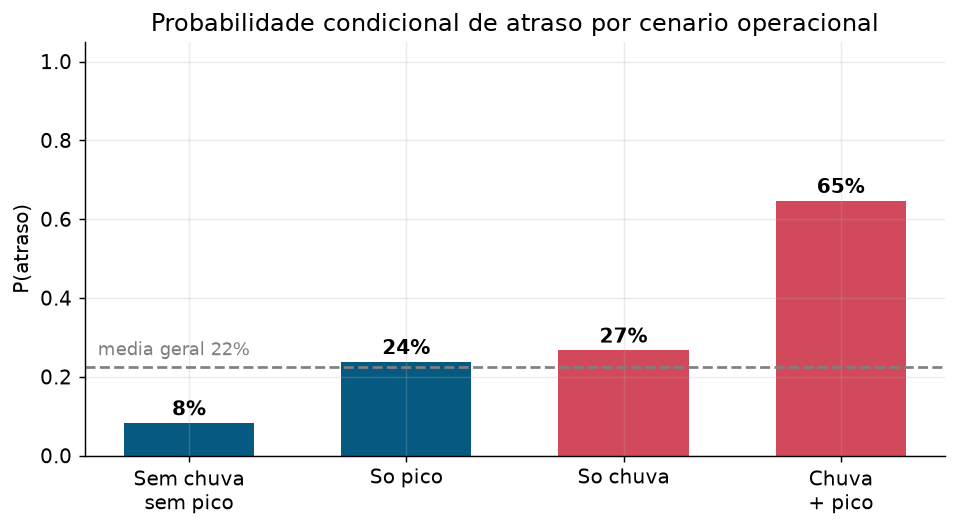


 3. DISTRIBUICAO NORMAL - MODELANDO O TEMPO DE ENTREGA
Media (mu)                  : 48.94 min
Desvio-padrao (sigma)       : 15.42 min
Mediana                     : 48.70 min
Assimetria                  : 0.137 (0 = simetrica)
Curtose                     : 0.027 (0 = normal)

Shapiro-Wilk: W = 0.9948 | p-valor = 0.0925
Conclusao   : nao rejeitamos H0 -> compativel com a Normal

--- Regra empirica (68-95-99,7) ---
  mu +/- 1 sigma -> teorico 68.27% | observado 67.00%
  mu +/- 2 sigma -> teorico 95.45% | observado 95.90%
  mu +/- 3 sigma -> teorico 99.73% | observado 99.80%

--- Probabilidade de estourar o SLA de 60 min ---
z = (60 - 48.94) / 15.42 = 0.717
P(T > 60) pela Normal   : 0.237
P(T > 60) empirica      : 0.225
Prazo que cobre 95% das entregas: 74.3 min


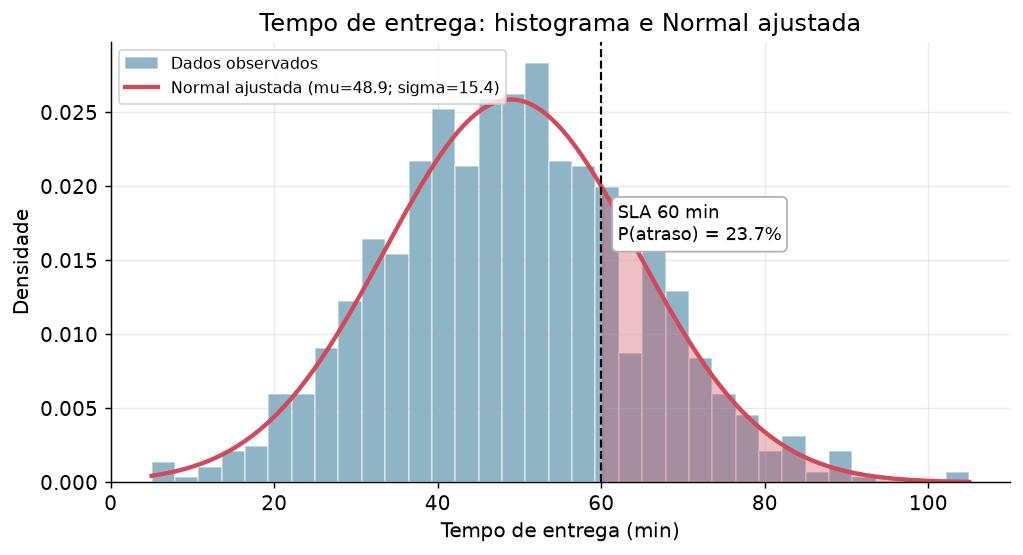

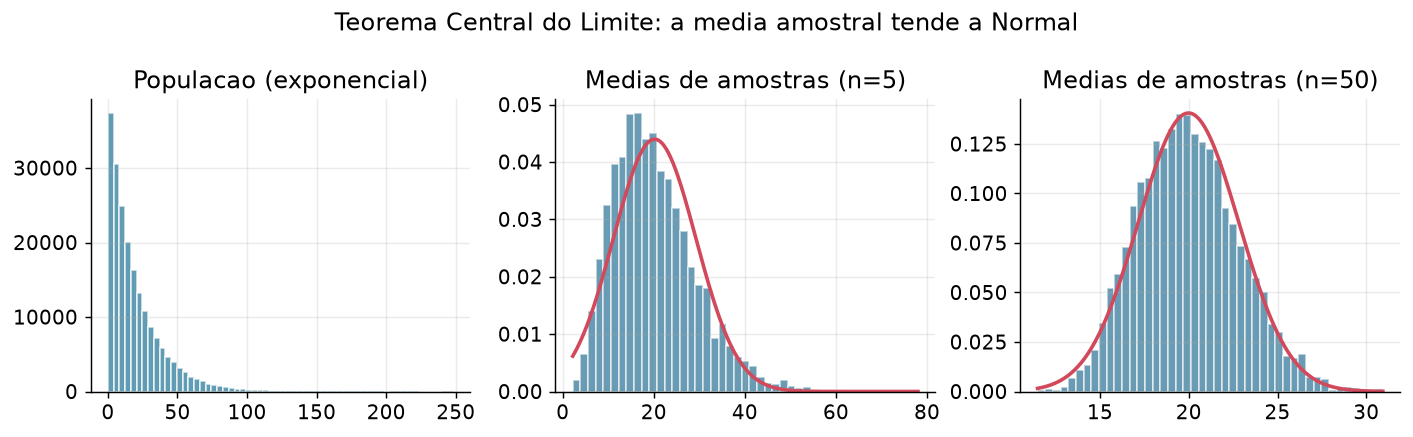


 4. IA - CLASSIFICADOR NAIVE BAYES GAUSSIANO (DO ZERO)
Treino: 700 entregas | Teste: 300 entregas

Classe 0 (NO PRAZO):
  P(classe) = 0.784
  distancia_km   mu =   10.80 | sigma =   3.36
  chuva          mu =    0.21 | sigma =   0.41
  horario_pico   mu =    0.32 | sigma =   0.47

Classe 1 (ATRASO):
  P(classe) = 0.216
  distancia_km   mu =   15.90 | sigma =   2.99
  chuva          mu =    0.61 | sigma =   0.49
  horario_pico   mu =    0.66 | sigma =   0.48

--- Desempenho no conjunto de teste ---
Acuracia : 0.873
Precisao : 0.891
Recall   : 0.554
F1-score : 0.683

Matriz de confusao
                previu no prazo  previu atraso
real: no prazo              221              5
real: atraso                 33             41

--- Simulacao de novos cenarios ---
            cenario  distancia_km  chuva  horario_pico  P(atraso)
   Curta, tempo bom             5      0             0      0.000
       Media, chuva            12      1             0      0.206
        Longa, pico            1

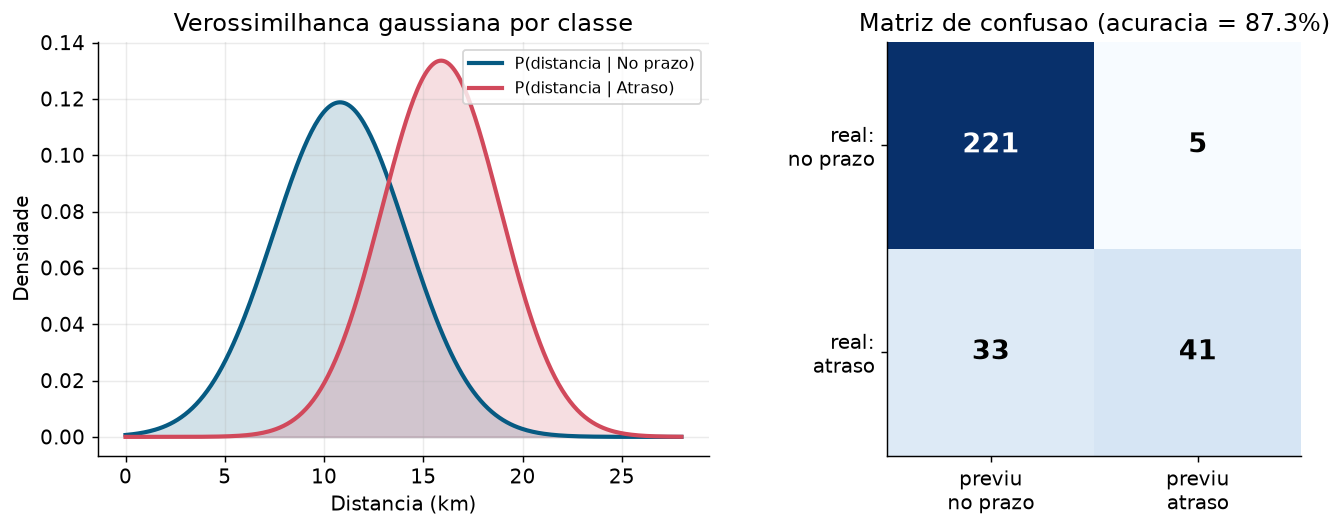


 5. SIMULACAO DE MONTE CARLO - CENARIOS DE DECISAO
Operacao atual                           P(atraso) = 23.73%
Roteirizacao por IA (-6 min na media)    P(atraso) = 13.55%
Frota padronizada (-25% no desvio)       P(atraso) = 16.43%
IA + frota (as duas acoes)               P(atraso) =  6.78%

Reducao absoluta do risco com as duas acoes: 16.95% (16950 entregas a menos atrasadas a cada 100 mil)


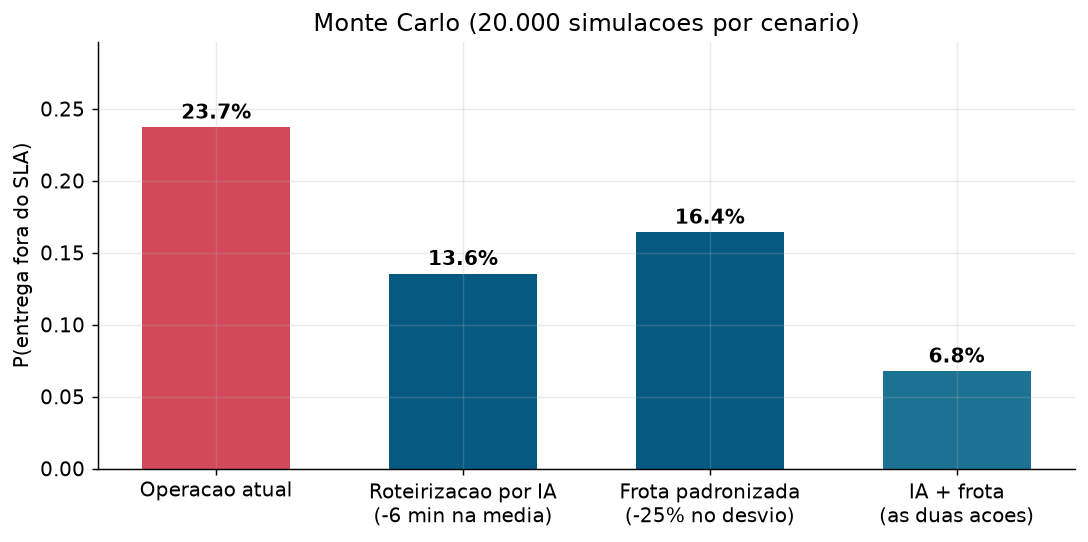


 6. SINTESE DOS RESULTADOS
P(atraso) geral................: 22.5%
P(atraso | chuva)..............: 41.0%
P(chuva | atraso) [Bayes]......: 56.0%
Tempo medio de entrega.........: 48.9 min (sigma = 15.4)
P(T > SLA) pela Normal.........: 23.7%
Acuracia do Naive Bayes........: 87.3%
Risco apos IA + frota (MC).....: 6.8%

Graficos salvos em: graficos


In [7]:
# ==============================================================
def main():
    titulo("1. BASE SIMULADA COM NUMEROS PSEUDOALEATORIOS (seed = 42)")
    df = gerar_base()
    print(df.head(8).to_string(index=False))
    print("\nResumo estatistico:")
    print(df.describe().round(2).to_string())

    prob = analise_probabilidade(df)
    normal = analise_normal(df)
    modelo = naive_bayes(df)
    mc = monte_carlo(normal["mu"], normal["sigma"])

    titulo("6. SINTESE DOS RESULTADOS")
    print(f"P(atraso) geral................: {prob['p_atraso']:.1%}")
    print(f"P(atraso | chuva)..............: {prob['p_atraso_chuva']:.1%}")
    print(f"P(chuva | atraso) [Bayes]......: {prob['p_chuva_dado_atraso']:.1%}")
    print(f"Tempo medio de entrega.........: {normal['mu']:.1f} min "
          f"(sigma = {normal['sigma']:.1f})")
    print(f"P(T > SLA) pela Normal.........: {normal['p_teorica']:.1%}")
    print(f"Acuracia do Naive Bayes........: {modelo['acuracia']:.1%}")
    print(f"Risco apos IA + frota (MC).....: "
          f"{mc['IA + frota' + chr(10) + '(as duas acoes)']:.1%}")
    print(f"\nGraficos salvos em: {PASTA_GRAFICOS}")

    df.to_csv("base_entregas_simulada.csv", index=False)


main()